# Moodsic — E2E Video to Fusion + Clustered Song Pick

Run the PERCEIVE pipeline on a video. It detects a primary face per
frame (if any), predicts valence/arousal from scene and face, fuses
them (uncertainty‑aware), and draws an overlay.

Flow:
- Run Setup and Adapters.
- Optionally skim the Helpers.
- In the Experiment cell, set `VIDEO_PATH` and run.

Outputs:
- Time series plot of fused valence/arousal.
- Sample overlays (first and last processed frames).
- Optional: save a full overlay video.


This variant adds a MATCH stage that maps fused emotion to cluster-specific song picks.

In [1]:
# Setup: repo path + imports

import os, sys, math, time

from pathlib import Path

repo_root = Path.cwd()

if repo_root.name == 'notebooks':
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import numpy as np

try:
    import cv2
except Exception as e:
    raise RuntimeError(f'OpenCV (cv2) is required: {e}')
import matplotlib.pyplot as plt

from utils.runtime_driver import VideoPerceptionResult, perceive_video
print('Repo root:', repo_root)



Repo root: /Users/kevinmanuel/Documents/NUS-Project-Sem2/REPO


In [2]:
# Adapters (best‑effort): try both scene and face paths
scene_adapter = None
face_processor = None
face_adapter = None

try:
    from models.scene.clip_vit_scene_adapter import SceneCLIPAdapter
    scene_adapter = SceneCLIPAdapter(
        model_name='openai/clip-vit-base-patch32',
        dropout_rate=0.3,
        device='auto',
        tta=3,
    )
    print('SceneCLIPAdapter: OK')
except Exception as e:
    print(f'SceneCLIPAdapter unavailable (transformers/weights/device): {e}')

try:
    from utils.emonet_single_face_processor import EmoNetSingleFaceProcessor
    face_processor = EmoNetSingleFaceProcessor(min_detection_confidence=0.5, padding_ratio=0.2)
    print('Face processor:', 'available' if getattr(face_processor, 'available', False) else 'unavailable')
except Exception as e:
    print(f'Face processor unavailable (mediapipe missing?): {e}')

try:
    from models.face.emonet_adapter import EmoNetAdapter
    face_adapter = EmoNetAdapter(
        ckpt_dir='models/emonet/pretrained',
        n_classes=8,
        device='auto',
        tta=3,
        calibration_checkpoint=None,
    )
    print('EmoNetAdapter: OK')
except Exception as e:
    print(f'EmoNetAdapter unavailable (torch/weights/device): {e}')


SceneCLIPAdapter: failed torch.load on /Users/kevinmanuel/Documents/NUS-Project-Sem2/REPO/scene/checkpoints/clip_vit-b32_model_improved_learner.pkl: Weights only load failed. This file can still be loaded, to do so you have two options, do those steps only if you trust the source of the checkpoint. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL fastai.learner.Learner was not an allowed global by default. Please use `torch.serialization.add_safe_globals([fastai.learner.Learner])` or the `torch.serialization.safe_globals([fastai.learner.Learner])` context manager to a

SceneCLIPAdapter: OK
Face processor: available
EmoNetAdapter: OK


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1759679840.153161 23718224 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


## EXPERIMENTATION

Instructions:
- Set `VIDEO_PATH` (absolute or repo‑relative).
- Adjust `SCENE_TTA`/`FACE_TTA`, `TARGET_SAMPLE_FPS`, and toggles as needed.
- Run the cell: `perceive_video(...)` handles frame iteration, overlays, and plots fused V/A.
- Optionally set `SAVE_OVERLAY_VIDEO=True` to save an annotated MP4.

Notes:
- TTA increases runtime roughly linearly; 3–5 is a good start.
- Stabilizer holds updates when fused variance is high; helps reduce jitter.


## Stabilization = False

I0000 00:00:1759679840.581623 23717885 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M3 Pro
W0000 00:00:1759679840.583059 23718263 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Video opened: /Users/kevinmanuel/Documents/NUS-Project-Sem2/REPO/data/videos/94.mp4 (1280x720 @ 25.00 fps, frames≈2064)
Processed frames: 83
Sampling stride: 25 (effective ≈ 1.00 fps)
----- Fusion -----
Mean valence: -0.19607494896736635
Mean arousal: -0.08808803921974273
Median valence: -0.20120998563193795
Median arousal: 0.05015598160534089
Mode valence: -0.39204642176628113
Mode arousal: -0.38099387288093567
----- Scene -----
Mean valence: -0.3638693713639156
Mean arousal: -0.5634609247187534
Median valence: -0.34039273858070374
Median arousal: -0.5486814975738525
Mode valence: -0.39204642176628113
Mode arousal: -0.38099387288093567
----- Face -----
Mean valence: -0.056630919195918575
Mean arousal: 0.24234655405463718
Median valence: -0.12850301930059987
Median arousal: 0.22764681776364643
Mode valence: -0.19051628559827805
Mode arousal: 0.1837921440601349


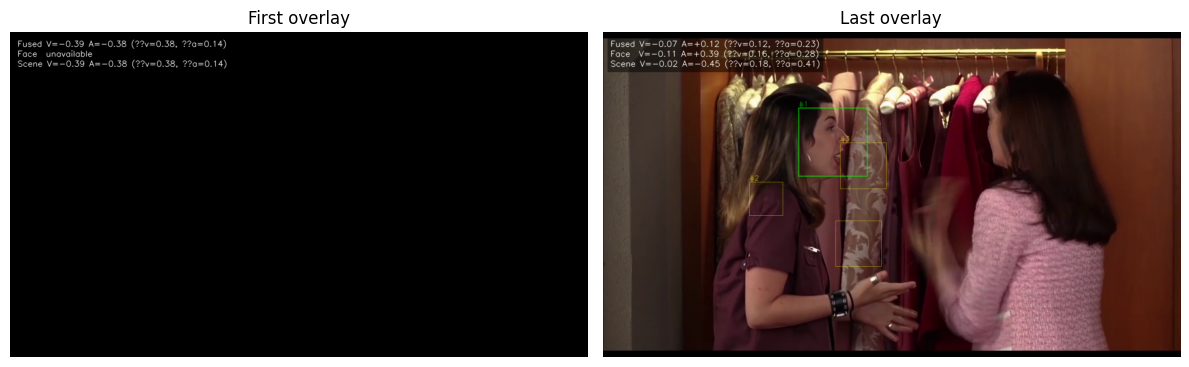

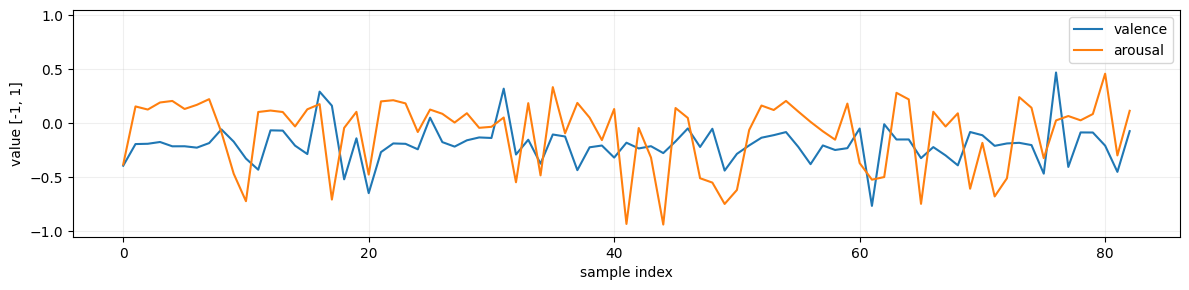

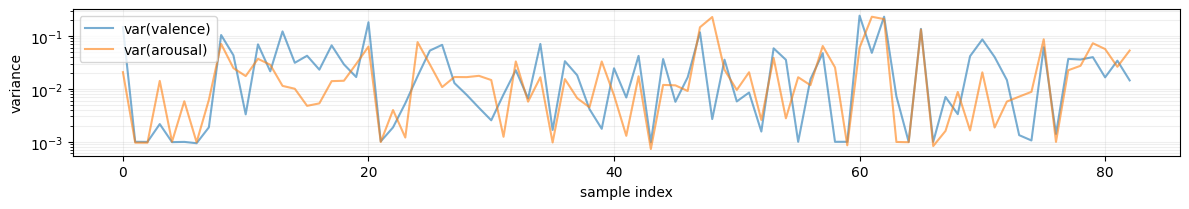

In [3]:
# Experiment: set the video and run

VIDEO_PATH = 'data/videos/94.mp4'  # set to your video

# Runtime/config
SCENE_TTA = 3
FACE_TTA = 3
USE_VARIANCE_WEIGHTING = True
ENABLE_STABILIZER = False
UNCERTAINTY_THRESHOLD = 0.4
STABILIZER_WINDOW = 60
TARGET_SAMPLE_FPS = 1.0      # desired processed frames per second
MAX_FRAMES = None           # e.g., 600 to cap processing

# Overlay video output (optional)
SAVE_OVERLAY_VIDEO = False
OVERLAY_OUT = 'outputs/overlay_fusion.mp4'

src = Path(VIDEO_PATH)
if not src.exists():
    alt = repo_root / VIDEO_PATH
    if alt.exists():
        src = alt

result = perceive_video(
    src,
    scene_predictor=scene_adapter,
    face_processor=face_processor,
    face_expert=face_adapter,
    scene_tta=SCENE_TTA,
    face_tta=FACE_TTA,
    target_sample_fps=TARGET_SAMPLE_FPS,
    max_frames=MAX_FRAMES,
    use_variance_weighting=USE_VARIANCE_WEIGHTING,
    enable_stabilizer=ENABLE_STABILIZER,
    uncertainty_threshold=UNCERTAINTY_THRESHOLD,
    stabilizer_window=STABILIZER_WINDOW,
    save_overlay_to=OVERLAY_OUT if SAVE_OVERLAY_VIDEO else None,
)

frame_total = result.frame_count if result.frame_count is not None else 'unknown'
print(
    f"Video opened: {result.video_path} ({result.width}x{result.height} @ {result.fps:.2f} fps, frames≈{frame_total})"
)
print(f'Processed frames: {result.processed_frames}')
print(f'Sampling stride: {result.sample_stride} (effective ≈ {result.effective_fps:.2f} fps)')

def _show_stats(name, series):
    print(f'----- {name} -----')
    print(f"Mean valence: {series.mean_valence}")
    print(f"Mean arousal: {series.mean_arousal}")
    print(f"Median valence: {series.median_valence}")
    print(f"Median arousal: {series.median_arousal}")
    print(f"Mode valence: {series.mode_valence}")
    print(f"Mode arousal: {series.mode_arousal}")

_show_stats('Fusion', result.fusion_result)
_show_stats('Scene', result.scene_result)
_show_stats('Face', result.face_result)
if result.overlay_path:
    print(f'Overlay video saved to: {result.overlay_path}')

first_overlay, last_overlay = result.first_overlay, result.last_overlay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
if first_overlay is not None:
    axes[0].imshow(cv2.cvtColor(first_overlay, cv2.COLOR_BGR2RGB))
    axes[0].set_title('First overlay')
    axes[0].axis('off')
if last_overlay is not None:
    axes[1].imshow(cv2.cvtColor(last_overlay, cv2.COLOR_BGR2RGB))
    axes[1].set_title('Last overlay')
    axes[1].axis('off')
plt.tight_layout(); plt.show()

if result.valence:
    sample_indices = np.arange(len(result.frame_indices), dtype=int)
    vals = np.array(result.valence, dtype=float)
    aros = np.array(result.arousal, dtype=float)
    vvars = np.array(result.var_valence, dtype=float)
    avars = np.array(result.var_arousal, dtype=float)

    plt.figure(figsize=(12, 3))
    plt.plot(sample_indices, vals, label='valence', color='tab:blue')
    plt.plot(sample_indices, aros, label='arousal', color='tab:orange')
    plt.xlabel('sample index')
    plt.ylabel('value [-1, 1]')
    plt.ylim(-1.05, 1.05)
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.tight_layout(); plt.show()

    if not (np.isnan(vvars).all() and np.isnan(avars).all()):
        plt.figure(figsize=(12, 2.2))
        plt.plot(sample_indices, vvars, label='var(valence)', color='tab:blue', alpha=0.6)
        plt.plot(sample_indices, avars, label='var(arousal)', color='tab:orange', alpha=0.6)
        plt.xlabel('sample index')
        plt.ylabel('variance')
        plt.yscale('log')
        plt.grid(True, which='both', alpha=0.2)
        plt.legend(); plt.tight_layout(); plt.show()
else:
    print('No frames processed; check VIDEO_PATH or adapters availability.')


## Stabilization = True

Video opened: /Users/kevinmanuel/Documents/NUS-Project-Sem2/REPO/data/videos/94.mp4 (1280x720 @ 25.00 fps, frames≈2064)
Processed frames: 83
Sampling stride: 25 (effective ≈ 1.00 fps)
----- Fusion -----
Mean valence: -0.21457230153229204
Mean arousal: -0.10153813972177272
Median valence: -0.20846880278269084
Median arousal: -0.05917079150407962
Mode valence: -0.7613071799278259
Mode arousal: -0.7404394149780273
----- Scene -----
Mean valence: -0.3587898858570415
Mean arousal: -0.5720305170370154
Median valence: -0.3646860122680664
Median arousal: -0.5923920273780823
Mode valence: -0.7613071799278259
Mode arousal: -0.7404394149780273
----- Face -----
Mean valence: -0.05611927731402425
Mean arousal: 0.2406970561408714
Median valence: -0.12159865745343268
Median arousal: 0.22778605856001377
Mode valence: -0.19253847748041153
Mode arousal: 0.18320080637931824


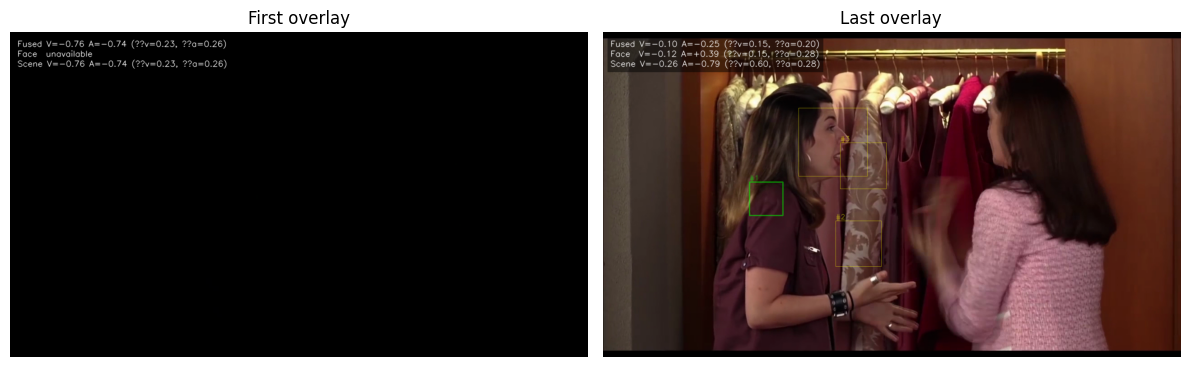

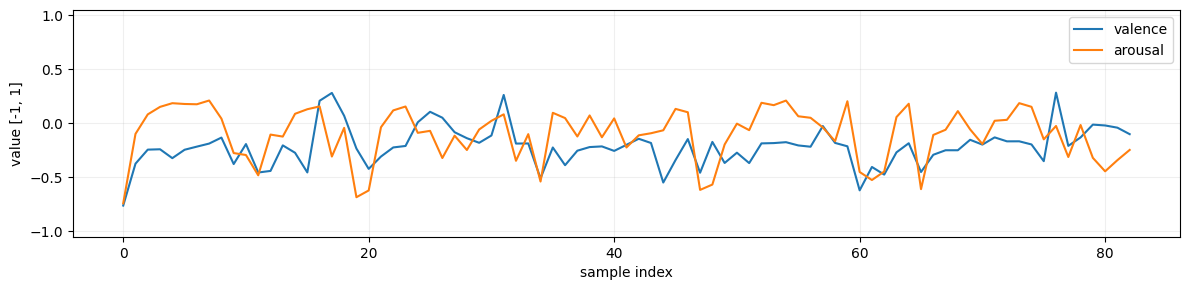

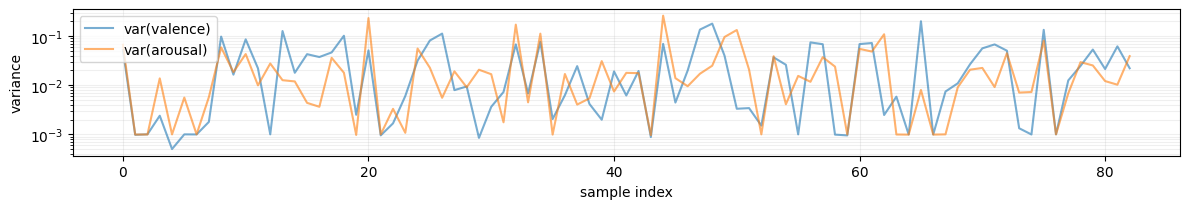

In [4]:
# Experiment: set the video and run

VIDEO_PATH = 'data/videos/94.mp4'  # set to your video

# Runtime/config
SCENE_TTA = 3
FACE_TTA = 3
USE_VARIANCE_WEIGHTING = True
ENABLE_STABILIZER = True
UNCERTAINTY_THRESHOLD = 0.4
STABILIZER_WINDOW = 60
TARGET_SAMPLE_FPS = 1.0      # desired processed frames per second
MAX_FRAMES = None           # e.g., 600 to cap processing

# Overlay video output (optional)
SAVE_OVERLAY_VIDEO = False
OVERLAY_OUT = 'outputs/overlay_fusion.mp4'

src = Path(VIDEO_PATH)
if not src.exists():
    alt = repo_root / VIDEO_PATH
    if alt.exists():
        src = alt

result = perceive_video(
    src,
    scene_predictor=scene_adapter,
    face_processor=face_processor,
    face_expert=face_adapter,
    scene_tta=SCENE_TTA,
    face_tta=FACE_TTA,
    target_sample_fps=TARGET_SAMPLE_FPS,
    max_frames=MAX_FRAMES,
    use_variance_weighting=USE_VARIANCE_WEIGHTING,
    enable_stabilizer=ENABLE_STABILIZER,
    uncertainty_threshold=UNCERTAINTY_THRESHOLD,
    stabilizer_window=STABILIZER_WINDOW,
    save_overlay_to=OVERLAY_OUT if SAVE_OVERLAY_VIDEO else None,
)

frame_total = result.frame_count if result.frame_count is not None else 'unknown'
print(
    f"Video opened: {result.video_path} ({result.width}x{result.height} @ {result.fps:.2f} fps, frames≈{frame_total})"
)

print(f'Processed frames: {result.processed_frames}')
print(f'Sampling stride: {result.sample_stride} (effective ≈ {result.effective_fps:.2f} fps)')

def _show_stats(name, series):
    print(f'----- {name} -----')
    print(f"Mean valence: {series.mean_valence}")
    print(f"Mean arousal: {series.mean_arousal}")
    print(f"Median valence: {series.median_valence}")
    print(f"Median arousal: {series.median_arousal}")
    print(f"Mode valence: {series.mode_valence}")
    print(f"Mode arousal: {series.mode_arousal}")

_show_stats('Fusion', result.fusion_result)
_show_stats('Scene', result.scene_result)
_show_stats('Face', result.face_result)
if result.overlay_path:
    print(f'Overlay video saved to: {result.overlay_path}')

first_overlay, last_overlay = result.first_overlay, result.last_overlay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
if first_overlay is not None:
    axes[0].imshow(cv2.cvtColor(first_overlay, cv2.COLOR_BGR2RGB))
    axes[0].set_title('First overlay')
    axes[0].axis('off')
if last_overlay is not None:
    axes[1].imshow(cv2.cvtColor(last_overlay, cv2.COLOR_BGR2RGB))
    axes[1].set_title('Last overlay')
    axes[1].axis('off')
plt.tight_layout(); plt.show()

if result.valence:
    sample_indices = np.arange(len(result.frame_indices), dtype=int)
    vals = np.array(result.valence, dtype=float)
    aros = np.array(result.arousal, dtype=float)
    vvars = np.array(result.var_valence, dtype=float)
    avars = np.array(result.var_arousal, dtype=float)

    plt.figure(figsize=(12, 3))
    plt.plot(sample_indices, vals, label='valence', color='tab:blue')
    plt.plot(sample_indices, aros, label='arousal', color='tab:orange')
    plt.xlabel('sample index')
    plt.ylabel('value [-1, 1]')
    plt.ylim(-1.05, 1.05)
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.tight_layout(); plt.show()

    if not (np.isnan(vvars).all() and np.isnan(avars).all()):
        plt.figure(figsize=(12, 2.2))
        plt.plot(sample_indices, vvars, label='var(valence)', color='tab:blue', alpha=0.6)
        plt.plot(sample_indices, avars, label='var(arousal)', color='tab:orange', alpha=0.6)
        plt.xlabel('sample index')
        plt.ylabel('variance')
        plt.yscale('log')
        plt.grid(True, which='both', alpha=0.2)
        plt.legend(); plt.tight_layout(); plt.show()
else:
    print('No frames processed; check VIDEO_PATH or adapters availability.')



## MATCH: Load Clustered Song Table

This workflow uses the precomputed DEAM valence/arousal clusters stored in
`notebooks/deam/artifacts/deam_gmm/deam_with_clusters.csv`. Each row represents
a song annotated with its cluster assignment and confidence. We will load the
rows with the standard library CSV reader to avoid optional dependencies.


In [5]:

from utils.song_cluster_matcher import ClusteredSongMatcher

ARTIFACTS_DIR = repo_root / "notebooks" / "Dataset - DEAM" / "artifacts" / "deam_gmm"
SONGS_CSV = ARTIFACTS_DIR / "deam_gmm_clusters.csv"

if not SONGS_CSV.exists():
    raise FileNotFoundError(f"Cluster CSV not found: {SONGS_CSV}")

matcher = ClusteredSongMatcher.from_artifacts(
    songs_csv=SONGS_CSV,
    artifacts_dir=ARTIFACTS_DIR,
)
print(f"Loaded {len(matcher.songs)} songs. Clusters: {len(matcher.centroids)}")


/opt/anaconda3/envs/p312/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Loaded 1802 songs. Clusters: 5


/opt/anaconda3/envs/p312/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator GaussianMixture from version 1.7.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(



## MATCH: Pick Cluster and Song

Using the fused mean valence/arousal from PERCEIVE, find the closest cluster
centroid and then select the song within that cluster whose valence/arousal is
closest to the target.


In [7]:

if 'result' not in locals():
    raise RuntimeError("Run the PERCEIVE experiment cell first to populate `result`.")
if result.processed_frames == 0:
    raise RuntimeError("No frames were processed; cannot recommend a song.")

fused_mean_val = result.fusion_result.mean_valence
fused_mean_aro = result.fusion_result.mean_arousal

if fused_mean_val is None or fused_mean_aro is None:
    import numpy as np
    vals = np.asarray(result.fusion_result.valence, dtype=float)
    aros = np.asarray(result.fusion_result.arousal, dtype=float)
    mask = np.isfinite(vals) & np.isfinite(aros)
    if not mask.any():
        raise RuntimeError("Fusion results do not contain finite valence/arousal values.")
    fused_mean_val = float(vals[mask].mean())
    fused_mean_aro = float(aros[mask].mean())

match = matcher.recommend(fused_mean_val, fused_mean_aro, top_k=5)

print(f"Target fused V/A: {match.target_valence:.3f}, {match.target_arousal:.3f}")
print(f"Gated clusters: {match.gated_clusters}")
for cluster_id in match.gated_clusters:
    posterior = match.cluster_posteriors.get(cluster_id)
    print(f"  cluster {cluster_id} posterior: {posterior:.3f}")

print("Best song (full metadata):")
for key in sorted(match.best_song.data):
    print(f"  {key}: {match.best_song.data[key]}")


Target fused V/A: -0.215, -0.102
Gated clusters: [3]
  cluster 3 posterior: 0.637
Best song (full metadata):
  arousal_ref: -0.10000000000000009
  artist: Dexter Britain
  cluster: 3
  cluster_conf: 0.6460340547885988
  genre: classical
  song_id: 241
  song_title: After The Week I've Had
  valence_ref: -0.2250000000000001



### Optional: Top Songs Within Cluster

Inspect the closest few candidates inside the chosen cluster.


In [8]:

print("Top candidates in gated clusters:")
for idx, candidate in enumerate(match.top_songs, start=1):
    print(f"#{idx}: distance={candidate.distance:.4f}")
    for key in sorted(candidate.data):
        print(f"  {key}: {candidate.data[key]}")


Top candidates in gated clusters:
#1: distance=0.0105
  arousal_ref: -0.10000000000000009
  artist: Dexter Britain
  cluster: 3
  cluster_conf: 0.6460340547885988
  genre: classical
  song_id: 241
  song_title: After The Week I've Had
  valence_ref: -0.2250000000000001
#2: distance=0.0105
  arousal_ref: -0.10000000000000009
  artist: Fred and Toody
  cluster: 3
  cluster_conf: 0.6460340547885988
  genre: rock
  song_id: 1917
  song_title: Let It Rain
  valence_ref: -0.2250000000000001
#3: distance=0.0257
  arousal_ref: -0.125
  artist: Volfoniq-Memori [Amentu Segretu
  cluster: 3
  cluster_conf: 0.5984514458445628
  genre: electronic
  song_id: 442
  song_title: Arrogalla remix feat Andrea Congia]
  valence_ref: -0.2250000000000001
#4: distance=0.0257
  arousal_ref: -0.125
  artist: un automne à Lob-Nor
  cluster: 3
  cluster_conf: 0.5984514458445628
  genre: rock
  song_id: 1380
  song_title: untitled
  valence_ref: -0.2250000000000001
#5: distance=0.0276
  arousal_ref: -0.125
  artis